# Modes of Convergence

There are several important notions describing how a sequence of random variables may converge.

## Almost Sure Convergence

We say that

$$
X_n
\overset{\mathrm{a.s.}}{\longrightarrow}
X
$$

if

$$
P\left(
\{\omega:X_n(\omega)\to X(\omega)\}
\right)=1.
$$

In words, the convergence holds for every outcome except possibly on a set of probability zero.

### Example

Consider the probability space $\Omega=[0,1]$, equipped with the Borel $\sigma$-algebra $\mathcal F=\mathcal B([0,1])$, and the Lebesgue probability measure. Define the sequence of random variables

$$
X_n(\omega)=\omega+\omega^n,
\qquad
\omega\in[0,1].
$$

We also define $X(\omega)=\omega$. It follows that,

$$
X_n
\overset{\mathrm{a.s.}}{\longrightarrow}
X.
$$

## Convergence in Probability

We say that

$$
X_n
\overset{P}{\longrightarrow}
X
$$

if for every $\varepsilon>0$,

$$
P(|X_n-X|>\varepsilon)
\longrightarrow0.
$$

This is the notion of convergence appearing in the Law of Large Numbers.

### Example

Let $X_n\sim\operatorname{Exp}(n)$. For every $\varepsilon>0$,

$$
P(|X_n|>\varepsilon)
=
P(X_n>\varepsilon)
=
e^{-n\varepsilon}\longrightarrow0.
$$

Hence

$$
X_n
\overset{P}{\longrightarrow}
0.
$$

## Convergence in Distribution

We say that

$$
X_n
\overset{d}{\longrightarrow}
X
$$

if

$$
F_{X_n}(x)\longrightarrow F_X(x)
$$

at every continuity point of $F_X$.

## Relationships Between Different Types of Convergence

In general, we have the following chain of implications:

$$
\boxed{
X_n
\overset{\mathrm{a.s.}}{\longrightarrow}
X
\quad\Longrightarrow\quad
X_n
\overset{P}{\longrightarrow}
X
\quad\Longrightarrow\quad
X_n
\overset{d}{\longrightarrow}
X.
}
$$

In general, **the converse implications are false**.

## Why Do We Study Different Modes of Convergence?

The various notions of convergence of random variables and random vectors are among the central concepts of modern probability theory.

They form the mathematical foundation of many advanced subjects, including Mathematical Statistics, Mathematical Finance and Stochastic Differential Equations.

Entire graduate courses are devoted to understanding the relationships between these different notions of convergence and learning the powerful theorems associated with them (Slutsky's theorem, the Continuous Mapping Theorem, Skorokhod's Representation Theorem, Prokhorov's Theorem, and many others).

Fortunately, **our goals in this course are much more modest.**

Since this is an introductory course in inferential statistics, we only need to understand

- the definitions of the main types of convergence;
- how to interpret them intuitively;
- where they appear in the Law of Large Numbers and the Central Limit Theorem.

# Limit Theorems

These theorems describe the behavior of random variables and random samples when the sample size becomes large. They form the mathematical foundation of modern statistics, statistical inference, and machine learning.

We begin with three fundamental results:

- Poisson Limit Theorem;
- Weak Law of Large Numbers (WLLN);
- Central Limit Theorem (CLT).

## Poisson Limit Theorem

The Poisson distribution naturally appears as the limit of a binomial distribution when the number of trials is large while the probability of success is small.

Let $X_n \sim \operatorname{Bin}(n,p_n)$, where

$$
n p_n \longrightarrow \lambda>0.
$$

Then for every fixed integer $k\ge0$,

$$
\boxed{
\lim_{n\to\infty}
P(X_n=k)
=
\frac{\lambda^k e^{-\lambda}}{k!}.
}
$$

In other words,

$$
X_n
\overset{d}{\longrightarrow}
\operatorname{Pois}(\lambda).
$$

This theorem explains why the Poisson distribution is widely used to model rare events.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

rng = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

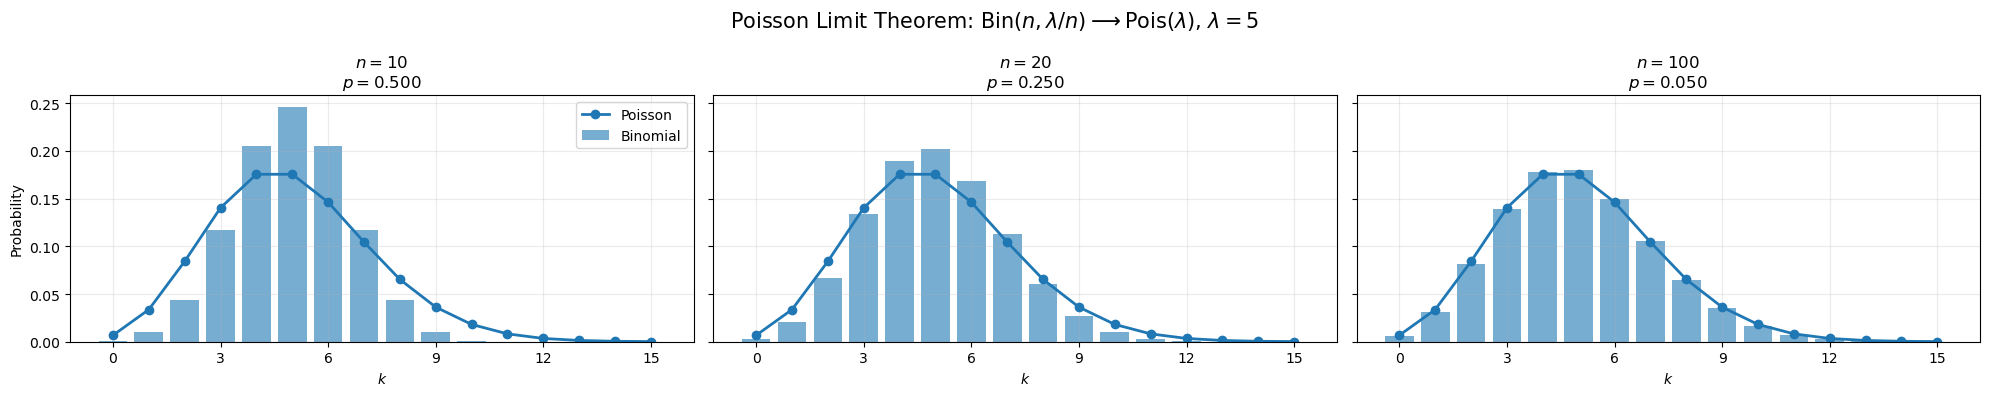

In [6]:
lambda_parameter = 5

sample_sizes = [10, 20, 100]

x_values = np.arange(0, 16)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sample_sizes),
    figsize=(20, 4),
    sharex=True,
    sharey=True
)

for axis, sample_size in zip(axes, sample_sizes):
    success_probability = lambda_parameter / sample_size

    binomial_probabilities = stats.binom.pmf(
        x_values,
        n=sample_size,
        p=success_probability
    )

    poisson_probabilities = stats.poisson.pmf(
        x_values,
        mu=lambda_parameter
    )

    axis.bar(
        x_values,
        binomial_probabilities,
        alpha=0.6,
        label="Binomial"
    )

    axis.plot(
        x_values,
        poisson_probabilities,
        marker="o",
        linewidth=2,
        label="Poisson"
    )

    axis.set_title(
        rf"$n={sample_size}$"
        "\n"
        rf"$p={success_probability:.3f}$"
    )

    axis.set_xlabel("$k$")
    axis.set_xticks(np.arange(0, 16, 3))

axes[0].set_ylabel("Probability")
axes[0].legend()

plt.suptitle(
    rf"Poisson Limit Theorem: "
    rf"$\operatorname{{Bin}}(n,\lambda/n)"
    rf"\longrightarrow\operatorname{{Pois}}(\lambda)$, "
    rf"$\lambda={lambda_parameter}$",
    fontsize=15
)

plt.tight_layout()
plt.show()

## Weak Law of Large Numbers

The Weak Law of Large Numbers states that sample averages become arbitrarily close to the population mean with high probability.

Let $X_1,X_2,\ldots$ be independent and identically distributed random variables satisfying

$$
E[X_i]=\mu,
\qquad
\operatorname{Var}(X_i)=\sigma^2<\infty.
$$

Define the sample sum $S_n=X_1+\cdots+X_n$. Then, for every $\varepsilon>0$,

$$
\boxed{
P\left(
\left|
\frac{S_n}{n}-\mu
\right|
>\varepsilon
\right)
\longrightarrow0.
}
$$

Equivalently,

$$
\frac{S_n}{n}
\overset{P}{\longrightarrow}
\mu.
$$

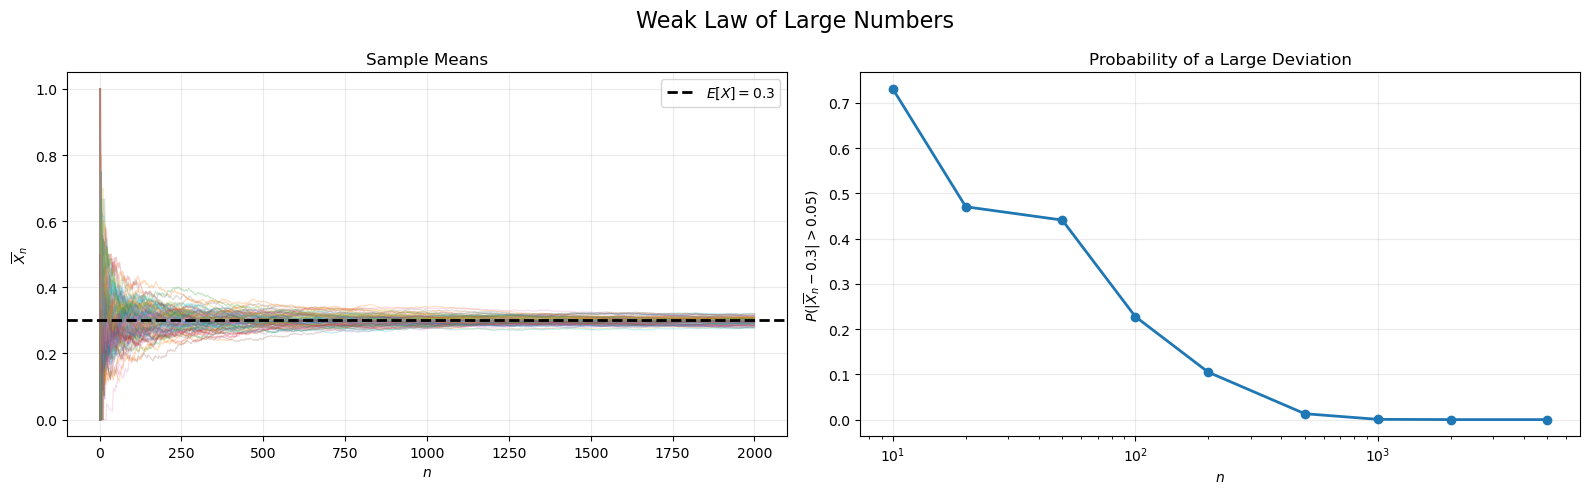

In [14]:
success_probability = 0.3
epsilon = 0.05

# --------------------------------------------------
# Parameters
# --------------------------------------------------

number_of_paths = 100
maximum_sample_size = 2000

sample_sizes = np.arange(1, maximum_sample_size + 1)

# --------------------------------------------------
# Left figure: sample means
# --------------------------------------------------

samples = rng.binomial(
    n=1,
    p=success_probability,
    size=(number_of_paths, maximum_sample_size)
)

running_means = (
    np.cumsum(samples, axis=1)
    / sample_sizes
)

# --------------------------------------------------
# Right figure:
# P(|X̄_n-p|>ε)
# --------------------------------------------------

sample_sizes_probability = np.array([
    10,
    20,
    50,
    100,
    200,
    500,
    1000,
    2000,
    5000
])

number_of_repetitions = 20_000

estimated_probabilities = []

for sample_size in sample_sizes_probability:

    sample_means = (
        rng.binomial(
            n=sample_size,
            p=success_probability,
            size=number_of_repetitions
        )
        / sample_size
    )

    estimated_probabilities.append(
        np.mean(
            np.abs(
                sample_means - success_probability
            ) > epsilon
        )
    )

estimated_probabilities = np.array(
    estimated_probabilities
)

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5)
)

# ---------------- Left ----------------

for path in running_means:
    axes[0].plot(
        sample_sizes,
        path,
        alpha=0.25,
        linewidth=0.8
    )

axes[0].axhline(
    success_probability,
    linestyle="--",
    linewidth=2,
    color="black",
    label=rf"$E[X]={success_probability}$"
)

axes[0].set_xlabel("$n$")
axes[0].set_ylabel(r"$\overline{X}_n$")
axes[0].set_title("Sample Means")
axes[0].legend()

# ---------------- Right ----------------

axes[1].plot(
    sample_sizes_probability,
    estimated_probabilities,
    marker="o",
    linewidth=2
)

axes[1].set_xscale("log")

axes[1].set_xlabel("$n$")
axes[1].set_ylabel(
    rf"$P(|\overline{{X}}_n-{success_probability}|>{epsilon})$"
)

axes[1].set_title("Probability of a Large Deviation")

# --------------------------------------------------

plt.suptitle(
    "Weak Law of Large Numbers",
    fontsize=16
)

plt.tight_layout()

plt.show()

## Central Limit Theorem

Unlike the Law of Large Numbers, which describes convergence to the mean, the Central Limit Theorem describes the fluctuations around the mean.

Let $X_1,X_2,\ldots$ be independent and identically distributed random variables satisfying

$$
E[X_i]=\mu,
\qquad
\operatorname{Var}(X_i)=\sigma^2>0.
$$

Then

$$
\boxed{
\frac{S_n-n\mu}
{\sigma\sqrt n}
\overset{d}{\longrightarrow}
N(0,1).
}
$$

The Central Limit Theorem is one of the most important results in probability and statistics since it explains why normal distributions appear so frequently in practice.

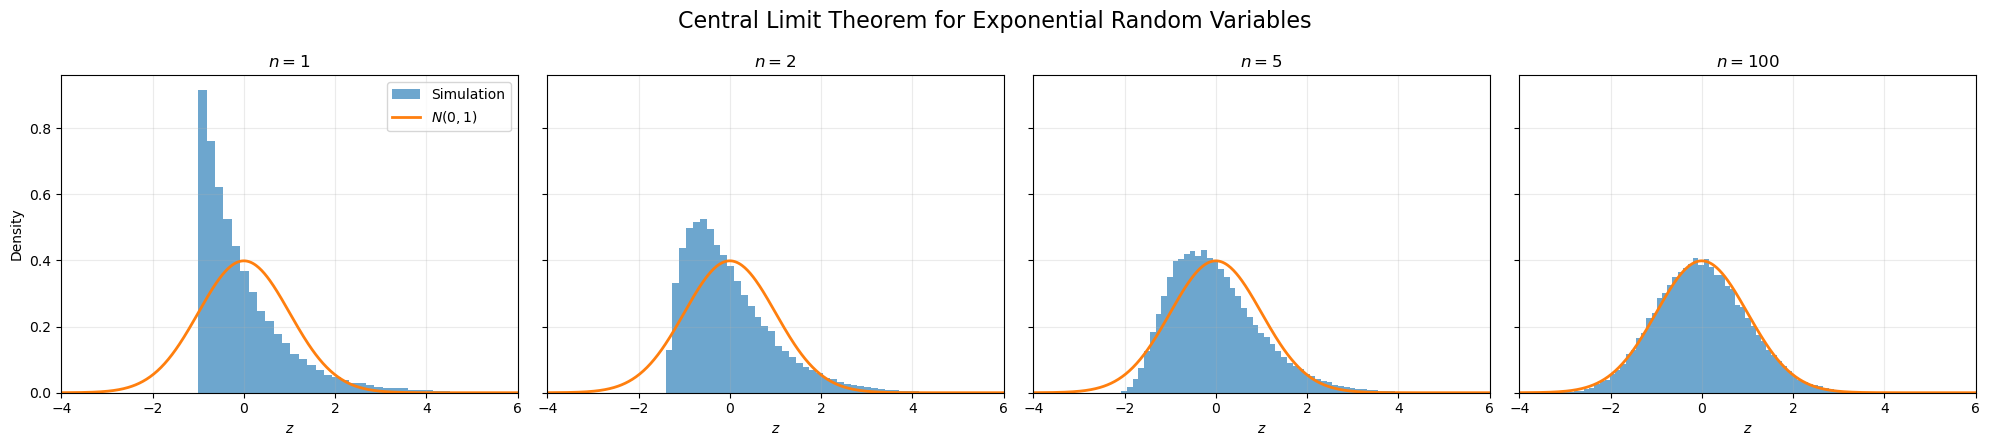

In [18]:
sample_sizes = [1, 2, 5, 100]
number_of_repetitions = 50_000

x_grid = np.linspace(-4, 6, 500)
normal_density = stats.norm.pdf(x_grid)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sample_sizes),
    figsize=(20, 4.5),
    sharex=True,
    sharey=True
)

for axis, sample_size in zip(axes, sample_sizes):

    sums = rng.gamma(
        shape=sample_size,
        scale=1,
        size=number_of_repetitions
    )

    standardized_sums = (
        sums - sample_size
    ) / np.sqrt(sample_size)

    axis.hist(
        standardized_sums,
        bins=70,
        density=True,
        alpha=0.65,
        label="Simulation"
    )

    axis.plot(
        x_grid,
        normal_density,
        linewidth=2,
        label=r"$N(0,1)$"
    )

    axis.set_xlim(-4, 6)
    axis.set_title(rf"$n={sample_size}$")
    axis.set_xlabel("$z$")

axes[0].set_ylabel("Density")
axes[0].legend()

plt.suptitle(
    "Central Limit Theorem for Exponential Random Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

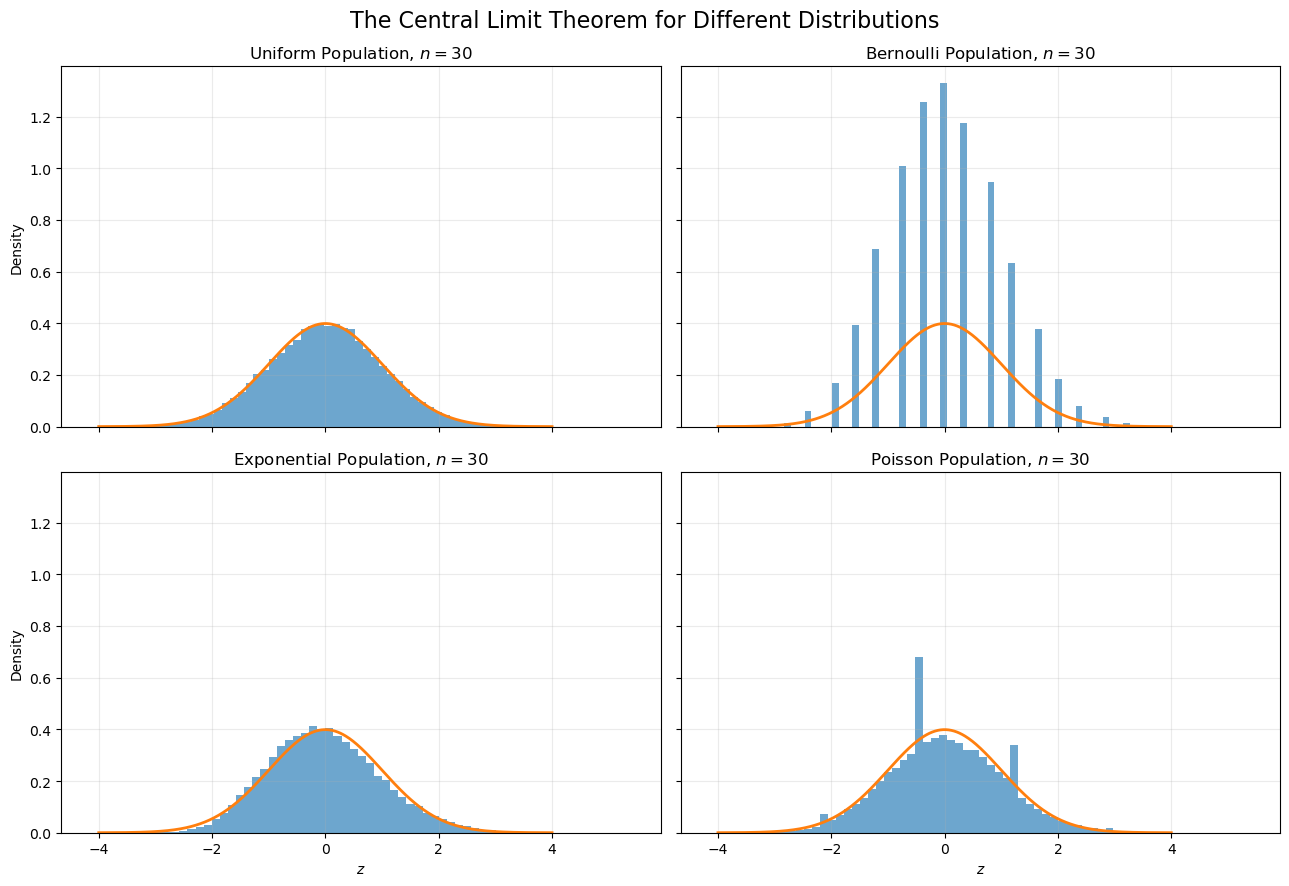

In [22]:
sample_size = 30
number_of_repetitions = 40_000

distributions = {
    "Uniform": {
        "sample": lambda shape: rng.uniform(
            low=-np.sqrt(3),
            high=np.sqrt(3),
            size=shape
        ),
        "mean": 0,
        "std": 1
    },
    "Bernoulli": {
        "sample": lambda shape: rng.binomial(
            n=1,
            p=0.3,
            size=shape
        ),
        "mean": 0.3,
        "std": np.sqrt(0.3 * 0.7)
    },
    "Exponential": {
        "sample": lambda shape: rng.exponential(
            scale=1,
            size=shape
        ),
        "mean": 1,
        "std": 1
    },
    "Poisson": {
        "sample": lambda shape: rng.poisson(
            lam=2,
            size=shape
        ),
        "mean": 2,
        "std": np.sqrt(2)
    }
}

x_grid = np.linspace(-4, 4, 500)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(13, 9),
    sharex=True,
    sharey=True
)

for axis, (name, information) in zip(
    axes.flat,
    distributions.items()
):
    samples = information["sample"](
        (number_of_repetitions, sample_size)
    )

    sample_sums = samples.sum(axis=1)

    standardized_sums = (
        sample_sums - sample_size * information["mean"]
    ) / (
        np.sqrt(sample_size) * information["std"]
    )

    axis.hist(
        standardized_sums,
        bins=60,
        density=True,
        alpha=0.65
    )

    axis.plot(
        x_grid,
        stats.norm.pdf(x_grid),
        linewidth=2
    )

    axis.set_title(
        rf"{name} Population, $n={sample_size}$"
    )

for axis in axes[-1, :]:
    axis.set_xlabel("$z$")

for axis in axes[:, 0]:
    axis.set_ylabel("Density")

plt.suptitle(
    "The Central Limit Theorem for Different Distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

# Law of the Iterated Logarithm

The Law of the Iterated Logarithm (LIL) describes the exact size of the largest fluctuations of a random walk.

While the Central Limit Theorem states that

$$
S_n-n\mu
=
O_P(\sqrt n),
$$

the Law of the Iterated Logarithm gives the precise almost sure asymptotic behavior.

Let $X_1,X_2,\ldots$ be independent and identically distributed random variables satisfying

$$
E[X_i]=0,
\qquad
E[X_i^2]=\sigma^2>0.
$$

Then

$$
\boxed{
P\left(
\limsup_{n\to\infty}
\frac{S_n}
{\sqrt{2\sigma^2 n\log\log n}}
=
1
\right)
=
1.
}
$$

Similarly,

$$
P\left(
\liminf_{n\to\infty}
\frac{S_n}
{\sqrt{2\sigma^2 n\log\log n}}
=
-1
\right)
=
1.
$$

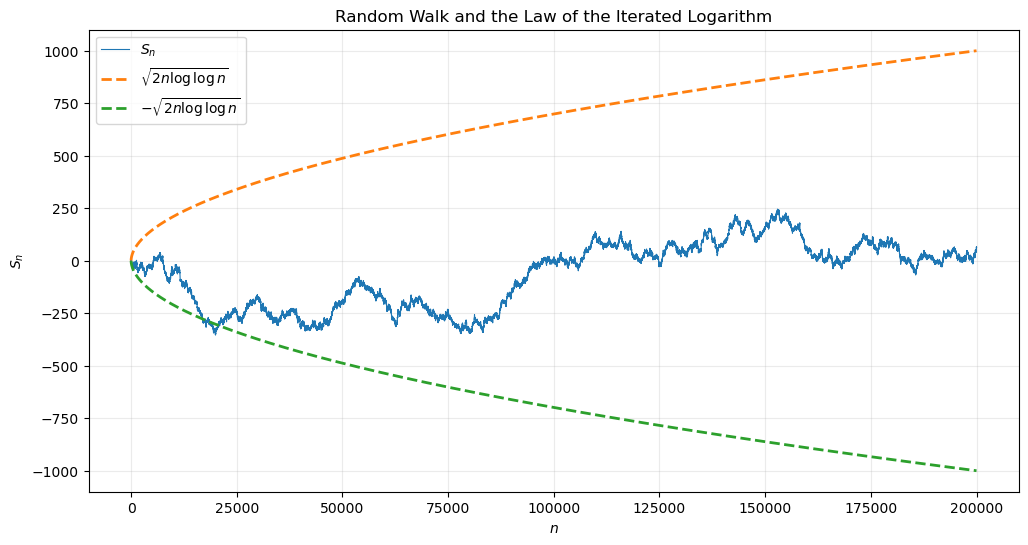

In [37]:
# --------------------------------------------------
# Reproducibility
# --------------------------------------------------

seed = 35
local_rng = np.random.default_rng(seed)

maximum_sample_size = 200_000

increments = local_rng.choice(
    [-1, 1],
    size=maximum_sample_size
)

partial_sums = np.cumsum(increments)

sample_sizes = np.arange(1, maximum_sample_size + 1)

valid_indices = sample_sizes >= 3

lil_envelope = np.full(
    maximum_sample_size,
    np.nan
)

lil_envelope[valid_indices] = np.sqrt(
    2
    * sample_sizes[valid_indices]
    * np.log(np.log(sample_sizes[valid_indices]))
)

plt.figure(figsize=(12, 6))

plt.plot(
    sample_sizes,
    partial_sums,
    linewidth=0.8,
    label="$S_n$"
)

plt.plot(
    sample_sizes,
    lil_envelope,
    "--",
    linewidth=2,
    label=r"$\sqrt{2n\log\log n}$"
)

plt.plot(
    sample_sizes,
    -lil_envelope,
    "--",
    linewidth=2,
    label=r"$-\sqrt{2n\log\log n}$"
)

plt.xlabel("$n$")
plt.ylabel("$S_n$")
plt.title("Random Walk and the Law of the Iterated Logarithm")
plt.legend()

plt.show()

# Multidimensional Central Limit Theorem

The Central Limit Theorem naturally extends to random vectors.

Let $X_1,X_2,\ldots \in\mathbb R^d$ be independent and identically distributed random vectors satisfying $E[X_i]=\mu$, and let $\Sigma=\operatorname{Cov}(X_i)$ be their covariance matrix.

Then

$$
\boxed{
\frac{S_n-n\mu}
{\sqrt n}
\overset{d}{\longrightarrow}
N(0,\Sigma)
}
$$


## Simulation: The Multidimensional Central Limit Theorem

In this simulation, we illustrate how the multidimensional Central Limit Theorem works.

We generate independent random vectors $X_1,X_2,\ldots,X_n\in\mathbb R^2$, where each coordinate is sampled independently from the uniform distribution

$$
U(-\sqrt{3},\sqrt{3}).
$$

The interval is chosen so that

$$
E[X_i]=
\begin{pmatrix}
0\\
0
\end{pmatrix},
\qquad
\operatorname{Cov}(X_i)=
I_2,
$$

where $I_2$ denotes the $2\times2$ identity matrix.

For each value of $n$, we compute the standardized sum

$$
Z_n
=
\frac{X_1+\cdots+X_n}{\sqrt n},
$$

and generate many independent realizations of $Z_n$. Each point in the scatter plot represents one realization of this random vector.

According to the Multidimensional Central Limit Theorem,

$$
Z_n
\overset{d}{\longrightarrow}
N(0,I_2),
$$

as $n\rightarrow\infty$.

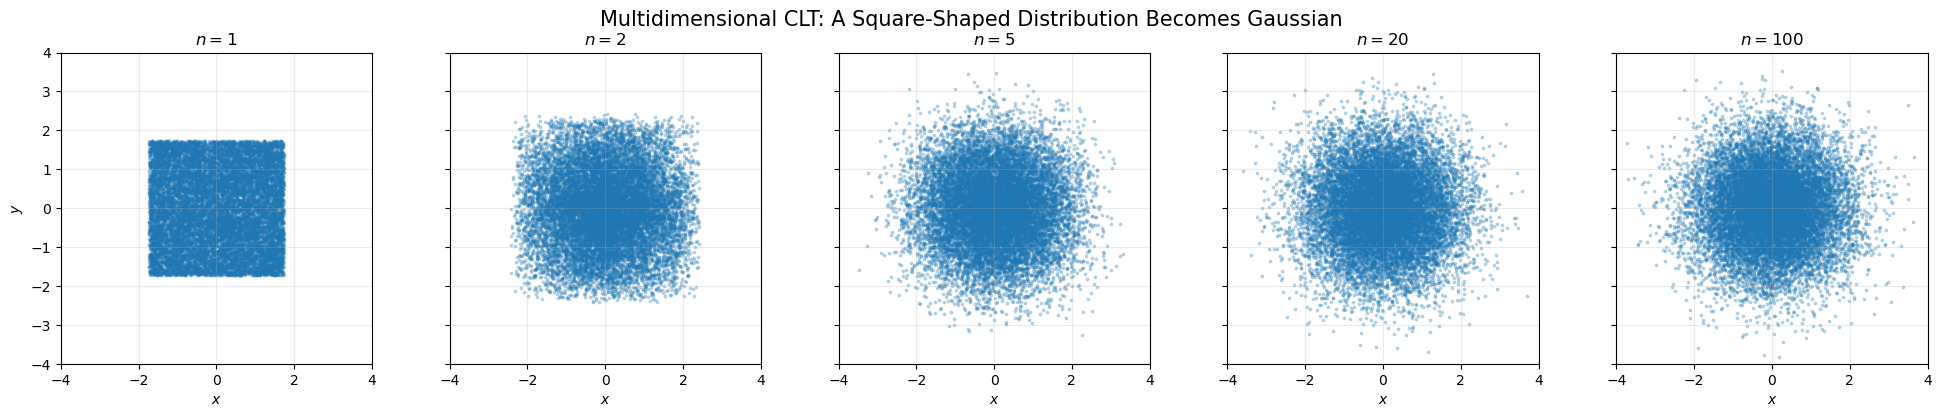

In [46]:
sample_sizes = [1, 2, 5, 20, 100]
number_of_repetitions = 15_000

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(sample_sizes),
    figsize=(20, 4),
    sharex=True,
    sharey=True
)

for axis, sample_size in zip(axes, sample_sizes):
    sample_sums = np.zeros(
        (number_of_repetitions, 2)
    )

    for _ in range(sample_size):
        sample_sums += rng.uniform(
            low=-np.sqrt(3),
            high=np.sqrt(3),
            size=(number_of_repetitions, 2)
        )

    standardized_sums = (
        sample_sums / np.sqrt(sample_size)
    )

    axis.scatter(
        standardized_sums[:, 0],
        standardized_sums[:, 1],
        s=3,
        alpha=0.25
    )

    axis.set_title(rf"$n={sample_size}$")
    axis.set_xlim(-4, 4)
    axis.set_ylim(-4, 4)
    axis.set_aspect("equal")

axes[0].set_ylabel("$y$")

for axis in axes:
    axis.set_xlabel("$x$")

plt.suptitle(
    "Multidimensional CLT: A Square-Shaped Distribution Becomes Gaussian",
    fontsize=15
)

plt.tight_layout()
plt.show()